In [1]:
#!pip install tqdm

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

from sklearn import linear_model
import lightgbm as lgbm
import catboost

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold




In [3]:
# Load data
X_train = pd.read_csv("data/X_train.csv", index_col="ROW_ID")
X_test = pd.read_csv("data/X_test.csv", index_col="ROW_ID")

y_train = pd.read_csv("data/y_train.csv", index_col="ROW_ID")
sample_submission = pd.read_csv("data/sample_submission.csv", index_col="ROW_ID")

### Features

In [4]:
import feature_eng
from importlib import reload

reload(feature_eng)
print(dir(feature_eng))

['FE_benchmark', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'add_rowwise_features', 'add_temporal_FE']


In [5]:
from feature_eng import FE_benchmark, add_rowwise_features
X_train, X_test, features = FE_benchmark(X_train, X_test)
X_train, X_test, features = add_rowwise_features(X_train, X_test, features)

In [6]:
X_train[features].head()

,RET_1,RET_2,RET_3,RET_4,RET_5,RET_6,RET_7,RET_8,RET_9,RET_10,...,vol_max_20,vol_pos_count_20,vol_mean_3,vol_mean_5,vol_mean_10,vol_trend_1_minus_5,vol_trend_5_minus_20,ret5_x_turnover,vol5_x_turnover,absret20_to_turnover
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,0.003944,-0.000178,0.001013,0.001514,-0.009067,0.002864,-0.009116,0.003312,0.001350,-0.009898,...,1.208587,16,0.072136,0.086381,0.336413,NaN,-0.526921,-0.000054,0.008371,0.042611
1,0.002323,0.000670,0.001383,-0.003427,0.000577,0.003323,0.003926,0.002878,-0.000259,-0.000376,...,-0.636931,0,-0.733898,-0.794794,-1.100634,NaN,1.006714,0.000003,-0.007927,0.204580
2,-0.000238,-0.002696,-0.003926,-0.000569,-0.002528,0.004384,-0.011090,-0.002392,0.006396,-0.006482,...,1.669319,19,0.380808,0.736525,0.816540,NaN,-0.131491,-0.000088,0.032544,0.109356
3,0.001863,0.001234,-0.003304,-0.007703,-0.000645,0.002725,-0.000178,0.000003,0.002596,-0.006420,...,-0.349882,0,-0.718917,-0.929260,-0.732850,NaN,-0.106361,-0.000002,-0.001069,2.966929
4,0.001219,-0.001040,-0.002409,-0.004260,0.000723,0.008469,0.004208,0.009455,-0.000475,0.000226,...,3.112834,13,0.992271,1.278511,0.908251,NaN,0.737191,NaN,NaN,NaN


### Fitting one simple Ridge

In [7]:
new_ridge = linear_model.Ridge(alpha=1)

new_ridge.fit(X_train[features].to_numpy(na_value=0), y_train.to_numpy(na_value=0))

preds_ridge = pd.DataFrame(
    new_ridge.predict(X_test[features].fillna(0).to_numpy(na_value=0)),
    index=sample_submission.index,
    columns=["target"],
)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=7.24336e-28): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


### Fitting a lightgbm using cross validation

In [8]:
print('lightgbm on bechmark + rowwise features and normal cv')
features_lgbm = features
# A quite large number of trees with low depth to prevent overfits
lgbm_params = {
    "objective": "mse",
    "metric": "mse",
    "num_threads": 50,
    "seed": 42,
    "verbosity": -1,
    "learning_rate": 1e-2,
    "max_depth": 3,
}
NUM_BOOST_ROUND = 500

train_dates = X_train["TS"].unique()
test_dates = X_test["TS"].unique()

n_splits = 8
scores_lgbm = []
models_lgbm = []

splits = KFold(
    n_splits=n_splits,
    random_state=0,
    shuffle=True,
).split(train_dates)

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train["TS"].isin(local_train_dates)
    local_test_ids = X_train["TS"].isin(local_test_dates)

    X_local_train = X_train.loc[local_train_ids, [x for x in features_lgbm]]
    y_local_train = y_train.loc[local_train_ids, "target"]

    X_local_test = X_train.loc[local_test_ids, [x for x in features_lgbm]]
    y_local_test = y_train.loc[local_test_ids, "target"]

    X_local_train = X_local_train
    X_local_test = X_local_test

    train_data = lgbm.Dataset(X_local_train, label=y_local_train.values)

    model_lgbm = lgbm.train(lgbm_params, train_data, num_boost_round=NUM_BOOST_ROUND)

    y_local_pred = model_lgbm.predict(
        X_local_test.values, num_threads=lgbm_params["num_threads"]
    )

    models_lgbm.append(model_lgbm)
    score = accuracy_score(
        (y_local_test > 0).astype(int), (y_local_pred > 0).astype(int)
    )
    scores_lgbm.append(score)
    print(f"Fold {i+1} - Accuracy: {score* 100:.2f}%")

mean = np.mean(scores_lgbm) * 100
std = np.std(scores_lgbm) * 100

u = mean + std
l = mean - std

print(f"Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})")

lightgbm on bechmark + rowwise features and normal cv
Fold 1 - Accuracy: 52.16%
Fold 2 - Accuracy: 52.40%
Fold 3 - Accuracy: 52.26%
Fold 4 - Accuracy: 52.42%
Fold 5 - Accuracy: 52.18%
Fold 6 - Accuracy: 52.47%
Fold 7 - Accuracy: 52.25%
Fold 8 - Accuracy: 51.90%
Accuracy: 52.26% [52.09 ; 52.43] (+- 0.17)


<Axes: >

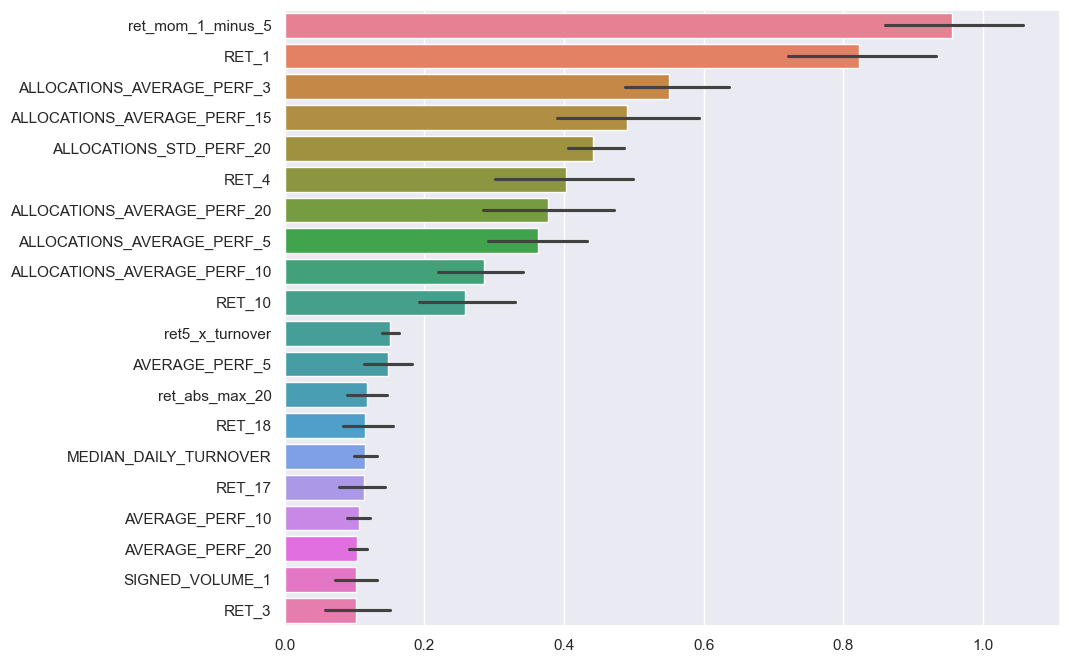

In [9]:
feature_importances = pd.DataFrame(
    [
        model_lgbm.feature_importance(importance_type="gain")
        for model_lgbm in models_lgbm
    ],
    columns=features_lgbm,
)

feature_importances = feature_importances.loc[
    :, feature_importances.mean(0).sort_values(ascending=False).index[:20]
]

plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importances,
    orient="h",
    order=feature_importances.mean().sort_values(ascending=False).index,
)

In [10]:
# train_data = lgbm.Dataset(X_train[features_lgbm], label=y_train)

# model_lgbm = lgbm.train(lgbm_params, train_data, num_boost_round=NUM_BOOST_ROUND)
# preds_lgbm = model_lgbm.predict(X_test[features_lgbm])
# preds_lgbm = pd.DataFrame(preds_lgbm, index=sample_submission.index, columns=["target"])

# # save to csv

# (preds_lgbm > 0).astype(int).to_csv("submissions/preds_lgbm_moreFE.csv")

# fitting Catboost with CV

In [11]:
# A quite large number of trees with low depth to prevent overfits

# this CV only work on the origina X_train and not on the X_train_reconstructed
# because it does not preserve the same TS distribution in the folds, 

catboost_features = features
print('catboost on benchmark + rowwise features and normal cv')


catboost_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 6,
    "verbose": False,
}

train_dates = X_train["TS"].unique()
scores_catboost = []
models_catboost = []

splits = KFold(
    n_splits=8,
    random_state=0,
    shuffle=True,
).split(train_dates)

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train["TS"].isin(local_train_dates)
    local_test_ids = X_train["TS"].isin(local_test_dates)

    X_local_train = X_train.loc[local_train_ids, features_lgbm]
    y_local_train = y_train.loc[local_train_ids, "target"]

    X_local_test = X_train.loc[local_test_ids, features_lgbm]
    y_local_test = y_train.loc[local_test_ids, "target"]

    train_data = catboost.Pool(X_local_train, label=y_local_train.values)

    model_catboost = catboost.CatBoostRegressor(**catboost_params)
    model_catboost.fit(train_data)

    y_local_pred = model_catboost.predict(X_local_test)

    models_catboost.append(model_catboost)
    score = accuracy_score(
        (y_local_test > 0).astype(int),
        (y_local_pred > 0).astype(int)
    )
    scores_catboost.append(score)

    print(f"Fold {i+1} - Accuracy: {score * 100:.2f}%")

mean_catboost = np.mean(scores_catboost) * 100
std_catboost = np.std(scores_catboost) * 100

print(
    f"Accuracy: {mean_catboost:.2f}% "
    f"[{mean_catboost - std_catboost:.2f} ; {mean_catboost + std_catboost:.2f}] "
    f"(+- {std_catboost:.2f})"
)

catboost on benchmark + rowwise features and normal cv
Fold 1 - Accuracy: 51.35%
Fold 2 - Accuracy: 52.21%
Fold 3 - Accuracy: 52.27%
Fold 4 - Accuracy: 52.10%
Fold 5 - Accuracy: 52.03%
Fold 6 - Accuracy: 52.11%
Fold 7 - Accuracy: 51.83%
Fold 8 - Accuracy: 51.76%
Accuracy: 51.96% [51.68 ; 52.24] (+- 0.28)


In [12]:
# train_data = catboost.Pool(X_train[features_lgbm], label=y_train)

# model_catboost = catboost.CatBoostRegressor(**catboost_params)
# model_catboost.fit(train_data)
# preds_catboost = model_catboost.predict(X_test[catboost_features])
# preds_catboost = pd.DataFrame(preds_catboost, index=sample_submission.index, columns=["target"])

# # save to csv
# (preds_catboost > 0).astype(int).to_csv("submissions/preds_catboost_moreFE.csv")

# Try to use the reconctructed 


In [ ]:
import feature_eng
from importlib import reload
reload(feature_eng)
print(dir(feature_eng))
import feature_eng

['FE_benchmark', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'add_rowwise_features', 'add_temporal_FE']


### lgbm temporal

In [32]:
from grid_search import lgbm_cv_temporal

In [15]:
def plot_feature_importances(models_lgbm, features_lgbm):
    feature_importances = pd.DataFrame(
        [
            model_lgbm.feature_importance(importance_type="gain")
            for model_lgbm in models_lgbm
        ],
        columns=features_lgbm,
    )

    feature_importances = feature_importances.loc[
        :, feature_importances.mean(0).sort_values(ascending=False).index[:20]
    ]

    plt.figure(figsize=(10, 8))

    sns.barplot(
        data=feature_importances,
        orient="h",
        order=feature_importances.mean().sort_values(ascending=False).index,
    )

Benchmark features only and temporal CV
Fold 1 | train: [DATE_0001 -> DATE_0280] | test: [DATE_0281 -> DATE_0560] | Accuracy: 50.16%
Fold 2 | train: [DATE_0001 -> DATE_0560] | test: [DATE_0561 -> DATE_0840] | Accuracy: 50.11%
Fold 3 | train: [DATE_0001 -> DATE_0840] | test: [DATE_0841 -> DATE_1120] | Accuracy: 50.67%
Fold 4 | train: [DATE_0001 -> DATE_1120] | test: [DATE_1121 -> DATE_1400] | Accuracy: 50.20%
Fold 5 | train: [DATE_0001 -> DATE_1400] | test: [DATE_1401 -> DATE_1680] | Accuracy: 50.30%
Fold 6 | train: [DATE_0001 -> DATE_1680] | test: [DATE_1681 -> DATE_1960] | Accuracy: 50.16%
Fold 7 | train: [DATE_0001 -> DATE_1960] | test: [DATE_1961 -> DATE_2240] | Accuracy: 50.41%
Fold 8 | train: [DATE_0001 -> DATE_2240] | test: [DATE_2241 -> DATE_2522] | Accuracy: 51.27%
Accuracy: 50.41% [50.04 ; 50.78] (+- 0.37)
Add rowwise features and temporal CV
Fold 1 | train: [DATE_0001 -> DATE_0280] | test: [DATE_0281 -> DATE_0560] | Accuracy: 50.16%
Fold 2 | train: [DATE_0001 -> DATE_0560] | 

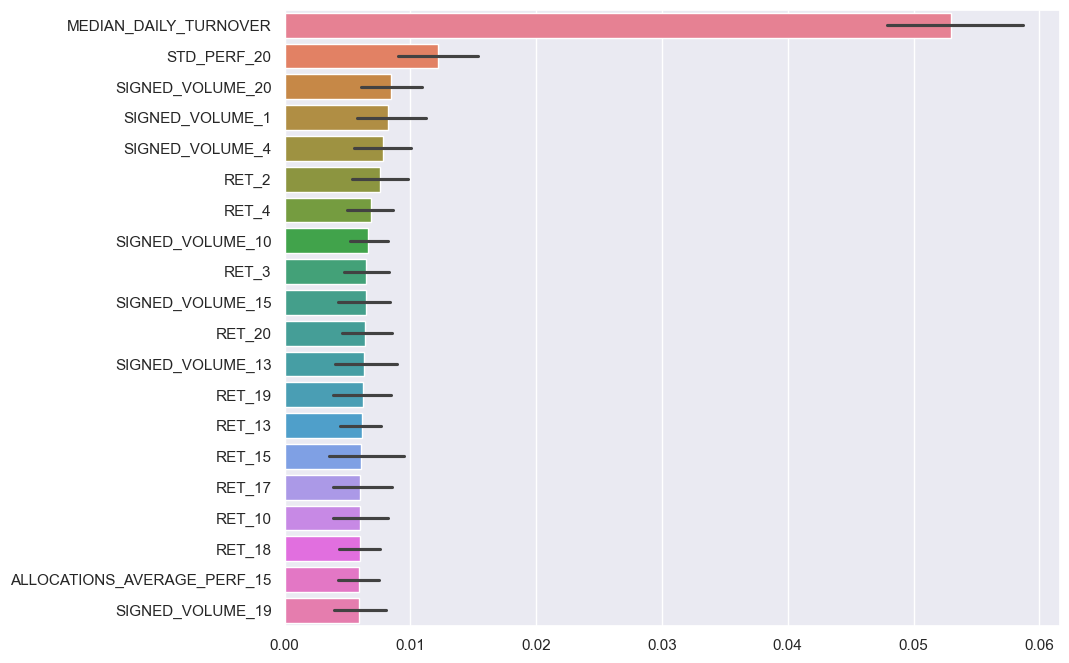

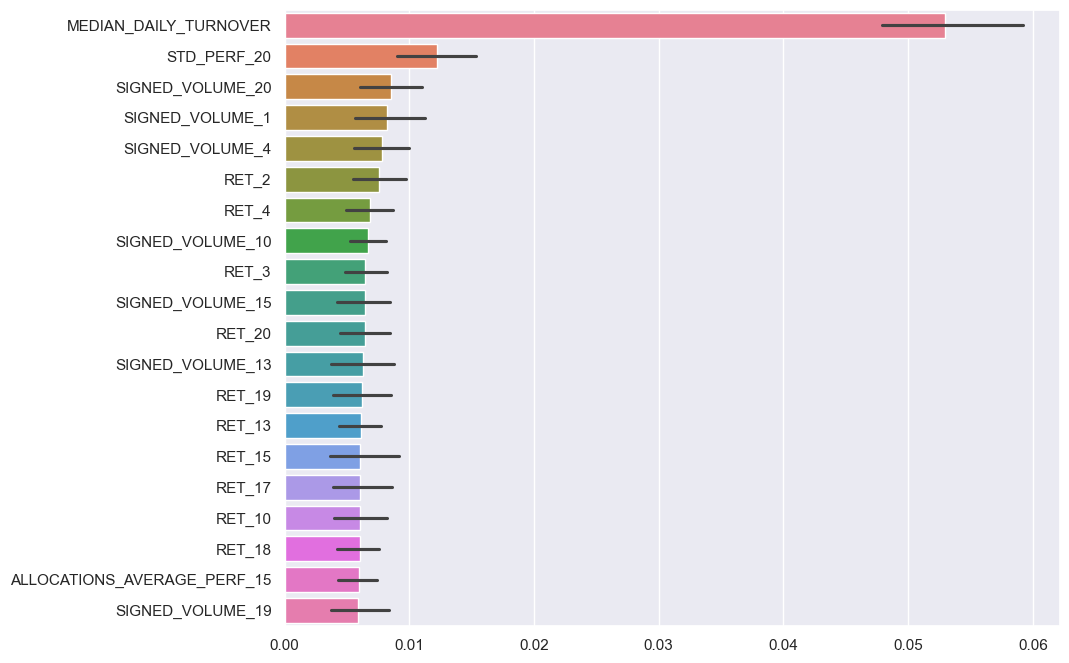

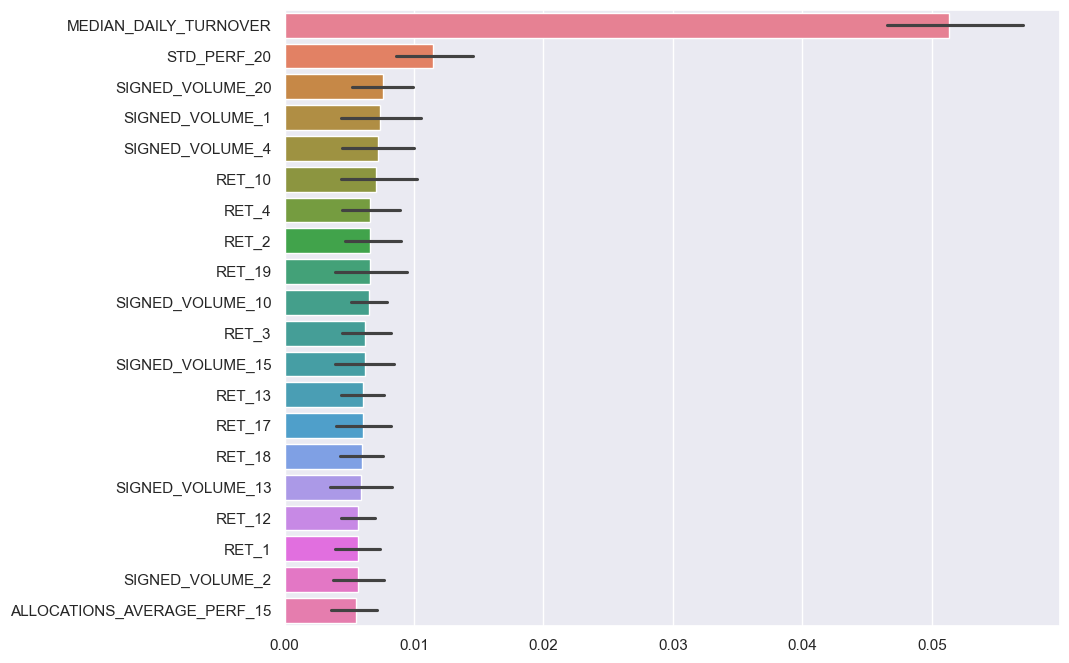

In [16]:
X_train_rec = pd.read_csv("data/X_train_reconstructed.csv", index_col="ROW_ID")

#only benchmark features
print("Benchmark features only and temporal CV")
X_train_rec, X_test, features = FE_benchmark(X_train_rec, X_test)
lgbm_models, lgbm_scores = lgbm_cv_temporal(X_train_rec, y_train, features)
plot_feature_importances(lgbm_models, features)

#now add rowwise features
print("Add rowwise features and temporal CV")
X_train_rec, X_test, features = add_rowwise_features(X_train_rec, X_test, features)
lgbm_models, lgbm_scores = lgbm_cv_temporal(X_train_rec, y_train, features)
plot_feature_importances(lgbm_models, features)

#add temporal features
print("Add temporal features and temporal CV")
X_train_rec, X_test, features = feature_eng.add_temporal_FE(X_train_rec, X_test, features)
lgbm_models, lgbm_scores = lgbm_cv_temporal(X_train_rec, y_train, features)
plot_feature_importances(lgbm_models, features)

In [17]:
# train_data = lgbm.Dataset(X_train[features_lgbm], label=y_train)

# model_lgbm = lgbm.train(lgbm_params, train_data, num_boost_round=NUM_BOOST_ROUND)
# preds_lgbm = model_lgbm.predict(X_test[features_lgbm])
# preds_lgbm = pd.DataFrame(preds_lgbm, index=sample_submission.index, columns=["target"])

# # save to csv
# (preds_lgbm > 0).astype(int).to_csv("submissions/preds_lgbm_temporal.csv")

## fitting Catboost with CV

In [ ]:
from grid_search import catboost_cv_temporal

In [ ]:
X_train_rec = pd.read_csv("data/X_train_reconstructed.csv", index_col="ROW_ID")

#only benchmark features
print("Benchmark features only and temporal CV")
X_train_rec, X_test, features = FE_benchmark(X_train_rec, X_test)
catboost_models, catboost_scores = catboost_cv_temporal(X_train_rec, y_train, features)

#now add rowwise features
print("Add rowwise features and temporal CV")
X_train_rec, X_test, features = add_rowwise_features(X_train_rec, X_test, features)
catboost_models, catboost_scores = catboost_cv_temporal(X_train_rec, y_train, features)

# add temporal features
print("Add temporal features and temporal CV")
X_train_rec, X_test, features = feature_eng.add_temporal_FE(X_train_rec, X_test, features)
catboost_models, catboost_scores = catboost_cv_temporal(X_train_rec, y_train, features)

Fold 1 | train: [DATE_0001 -> DATE_0280] | test: [DATE_0281 -> DATE_0560] | best_iter: 13 | Accuracy: 50.04%
Fold 2 | train: [DATE_0001 -> DATE_0560] | test: [DATE_0561 -> DATE_0840] | best_iter: 9 | Accuracy: 50.30%
Fold 3 | train: [DATE_0001 -> DATE_0840] | test: [DATE_0841 -> DATE_1120] | best_iter: 2 | Accuracy: 51.19%
Fold 4 | train: [DATE_0001 -> DATE_1120] | test: [DATE_1121 -> DATE_1400] | best_iter: 106 | Accuracy: 50.24%
Fold 5 | train: [DATE_0001 -> DATE_1400] | test: [DATE_1401 -> DATE_1680] | best_iter: 7 | Accuracy: 50.40%
Fold 6 | train: [DATE_0001 -> DATE_1680] | test: [DATE_1681 -> DATE_1960] | best_iter: 1 | Accuracy: 50.03%
Fold 7 | train: [DATE_0001 -> DATE_1960] | test: [DATE_1961 -> DATE_2240] | best_iter: 20 | Accuracy: 50.55%
Fold 8 | train: [DATE_0001 -> DATE_2240] | test: [DATE_2241 -> DATE_2522] | best_iter: 3 | Accuracy: 51.93%
Accuracy: 50.59% [49.97 ; 51.20] (+- 0.61)
Fold 1 | train: [DATE_0001 -> DATE_0280] | test: [DATE_0281 -> DATE_0560] | best_iter: 13

In [21]:
# train_data = catboost.Pool(X_train[features_lgbm], label=y_train)

# model_catboost = catboost.CatBoostRegressor(**catboost_params)
# model_catboost.fit(train_data)
# preds_catboost = model_catboost.predict(X_test[catboost_features])
# preds_catboost = pd.DataFrame(preds_catboost, index=sample_submission.index, columns=["target"])

# # save to csv
# (preds_catboost > 0).astype(int).to_csv("submissions/preds_catboost_moreFE.csv")

# Grid search